# A. Environment Introduction

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import gymnasium as gym

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})
print("gymnasium", gym.__version__)

gymnasium 1.3.0


**1. CartPole-v1**

In [2]:
env = gym.make("CartPole-v1")
print("Observation space:", env.observation_space)
print("\nLow:", env.observation_space.low)
print("\nHigh:", env.observation_space.high)
print("\nAction space:", env.action_space)
obs, info = env.reset(seed=0)
print("Observation đầu tiên:", obs)

env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

Low: [-4.8               -inf -0.41887903        -inf]

High: [4.8               inf 0.41887903        inf]

Action space: Discrete(2)
Observation đầu tiên: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]


**2. Acrobot-v1**

In [3]:
env = gym.make("Acrobot-v1")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
obs, info = env.reset(seed=0)
print("Observation đầu tiên:", obs)
u = env.unwrapped
print("Mô-men khả dụng:", u.AVAIL_TORQUE)
env.close()

Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Action space: Discrete(3)
Observation đầu tiên: [ 0.99962485  0.02738891  0.9989402  -0.04602639 -0.09180529 -0.09669447]
Mô-men khả dụng: [-1.0, 0.0, 1]


# Khung đánh giá dùng chung

Định nghĩa "thắng" cho mỗi môi trường:
- **CartPole:** sống sót ≥ 195 bước (chuẩn cổ điển).
- **Acrobot:** `terminated == True`, tức chạm mốc chiều cao trước khi hết 500 bước.

In [13]:
N_EPISODES = 100

def is_success(env_id, terminated, steps):
    if env_id.startswith("CartPole"):
        return steps >= 195
    if env_id.startswith("Acrobot"):
        return bool(terminated)
    return bool(terminated)

def evaluate(env_id, policy, n_episodes=N_EPISODES, seed=0, param_setter=None):
    """Chạy n_episodes tập, trả về thống kê. param_setter chỉnh tham số vật lý qua env.unwrapped."""
    env = gym.make(env_id)
    if param_setter is not None:
        param_setter(env.unwrapped)
    rewards, lengths, wins = [], [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        env.action_space.seed(seed + ep)
        total, steps, term, trunc = 0.0, 0, False, False
        while not (term or trunc):
            obs, r, term, trunc, _ = env.step(policy(obs, env))
            total += r; steps += 1
        rewards.append(total); lengths.append(steps)
        wins.append(is_success(env_id, term, steps))
    env.close()
    rewards, lengths = np.array(rewards), np.array(lengths, dtype=float)
    return {"mean_reward": rewards.mean(), "std_reward": rewards.std(),
            "mean_steps": lengths.mean(), "success_rate": 100 * np.mean(wins),
            "rewards": rewards}

def row(label, s):
    return {"Cấu hình": label, "Reward TB": round(s["mean_reward"], 2),
            "Độ lệch chuẩn": round(s["std_reward"], 2),
            "Số bước TB": round(s["mean_steps"], 1),
            "Tỉ lệ thắng (%)": round(s["success_rate"], 1)}

def setter(**kw):
    def f(u):
        for k, v in kw.items(): setattr(u, k, v)
    return f

# C. Manual Play, Random Agent, Simple Heuristic, stable-baselines3

**1. CartPole**

**1.1 Luôn đẩy sang phải**

In [4]:
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)
print(f"{'bước':>5} {'x':>8} {'x_dot':>8} {'theta°':>8} {'theta_dot':>10}  hành động")
for t in range(1, 40):
    action = 1                      # <-- đổi số này để "chơi tay"
    obs, r, term, trunc, _ = env.step(action)
    if t % 3 == 0 or term:
        print(f"{t:>5} {obs[0]:>8.3f} {obs[1]:>8.3f} "
              f"{np.degrees(obs[2]):>8.2f} {obs[3]:>10.3f}  {'phải' if action else 'trái'}")
    if term or trunc:
        print(f"\n>>> Kết thúc sau {t} bước. Góc cuối = {np.degrees(obs[2]):.2f}° (ngưỡng ±12°)")
        break
env.close()

 bước        x    x_dot   theta°  theta_dot  hành động
    3    0.039    0.578     1.16     -0.825  phải
    6    0.085    1.163    -2.67     -1.701  phải
    9    0.167    1.750    -9.59     -2.652  phải
   10    0.202    1.946   -12.62     -2.991  phải

>>> Kết thúc sau 10 bước. Góc cuối = -12.62° (ngưỡng ±12°)


**1.2 Chơi theo phản xạ**

In [6]:
def play_manual(plan, seed=42, env_id="CartPole-v1"):
    """plan: danh sách hành động. Trả về tổng reward."""
    env = gym.make(env_id)
    obs, _ = env.reset(seed=seed)
    total = 0
    for t, a in enumerate(plan, 1):
        obs, r, term, trunc, _ = env.step(a)
        total += r
        if term or trunc:
            print(f"Kết thúc ở bước {t}, tổng reward = {total}")
            env.close(); return total
    print(f"Hết chuỗi hành động sau {len(plan)} bước, tổng reward = {total}, "
          f"góc hiện tại = {np.degrees(obs[2]):.2f}°")
    env.close(); return total

print("— Luôn đẩy phải:");       play_manual([1] * 100)
print("\n— Trái/phải xen kẽ:");   play_manual([0, 1] * 50)
print("\n— Hai phải một trái:");  play_manual([1, 1, 0] * 34)

— Luôn đẩy phải:
Kết thúc ở bước 10, tổng reward = 10.0

— Trái/phải xen kẽ:
Kết thúc ở bước 23, tổng reward = 23.0

— Hai phải một trái:
Kết thúc ở bước 15, tổng reward = 15.0


15.0

**2. Acrobot**

Chỉ chơi bằng tay thì không thể nào cho thể đẩy được nó lên vị trí mà mình mong muốn -> chỉ đẩy 1 chiều thôi

Luôn đẩy một chiều: 500 bước, reward = -500.0, đạt đích = False
Chiều cao lớn nhất đạt được = -1.879 (cần > 1.0)


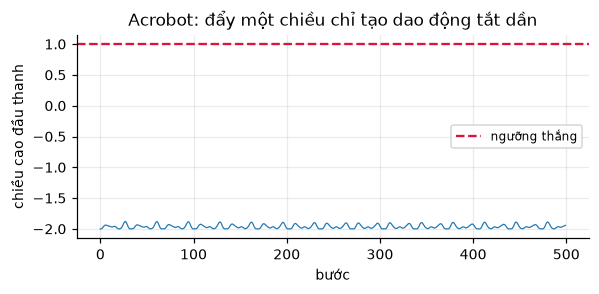

In [8]:
env = gym.make("Acrobot-v1")
obs, _ = env.reset(seed=0)
total = 0
heights = []
for t in range(500):
    obs, r, term, trunc, _ = env.step(2)   # luôn +1 N·m
    total += r
    h = -obs[0] - (obs[0] * obs[2] - obs[1] * obs[3])   # -cos(t1) - cos(t1+t2)
    heights.append(h)
    if term: break
print(f"Luôn đẩy một chiều: {t+1} bước, reward = {total}, đạt đích = {term}")
print(f"Chiều cao lớn nhất đạt được = {max(heights):.3f} (cần > 1.0)")

plt.figure(figsize=(6, 2.4))
plt.plot(heights, lw=.8); plt.axhline(1.0, color="crimson", ls="--", label="ngưỡng thắng")
plt.xlabel("bước"); plt.ylabel("chiều cao đầu thanh"); plt.legend(fontsize=8)
plt.title("Acrobot: đẩy một chiều chỉ tạo dao động tắt dần"); plt.show()

Nhìn đồ thị ta có thể thấy là khi đẩy 1 chiều thì nó chỉ đạt đến 1 giá trị giữa sau đó dao động xung quanh và không bao giờ đủ năng lượng. Muốn thắng thì phải đẩy liên tục 2 chiều so le nhau.

# C. Manual Play, Random Agent, Simple Heuristic, stable-baselines3

## Thiết kế các heuristic

**CartPole**
- **H1 — chỉ nhìn góc:** `nghiêng phải → đẩy phải`. Trực giác đúng nhưng thiếu thông tin.
- **H2 — bộ điều khiển PD:** `u = θ + 0.5·θ̇`. Thêm số hạng đạo hàm giúp *dự đoán trước* thay vì phản ứng muộn.
- **H3 — PD + giữ xe ở tâm:** `u = θ + 0.5·θ̇ + 0.02·x + 0.05·ẋ`, chống việc xe trôi dần ra khỏi ±2.4.

**Acrobot**
- **H1 — mô-men cố định:** luôn `+1`, dùng làm mốc so sánh.
- **H2 — bơm năng lượng:** đẩy mô-men **cùng dấu với `θ̇2`**. Công = mô-men × vận tốc góc, nên cùng dấu
  nghĩa là **luôn bơm năng lượng vào hệ** ở mọi bước. Đây là luật xích đu viết bằng một dòng.

In [9]:
def random_agent(obs, env): return env.action_space.sample()

# --- CartPole ---
def cartpole_naive(obs, env):
    return 1 if obs[2] > 0 else 0

def cartpole_pd(obs, env):
    return 1 if obs[2] + 0.5 * obs[3] > 0 else 0

def cartpole_pd_full(obs, env):
    x, x_dot, th, th_dot = obs
    return 1 if th + 0.5 * th_dot + 0.02 * x + 0.05 * x_dot > 0 else 0

# --- Acrobot ---
def acrobot_naive(obs, env): return 2

def acrobot_pump(obs, env):
    return 2 if obs[5] > 0 else 0  

In [14]:
cp_agents = [("Random", random_agent),
             ("H1: chỉ nhìn góc", cartpole_naive),
             ("H2: PD (góc + vận tốc góc)", cartpole_pd),
             ("H3: PD + giữ xe ở tâm", cartpole_pd_full)]

cp_stats = {n: evaluate("CartPole-v1", p) for n, p in cp_agents}
df_cp = pd.DataFrame([row(n, s) for n, s in cp_stats.items()])
print("CartPole-v1 — 100 tập / agent"); display(df_cp)

CartPole-v1 — 100 tập / agent


,Cấu hình,Reward TB,Độ lệch chuẩn,Số bước TB,Tỉ lệ thắng (%)
0,Random,24.96,15.38,25.0,0.0
1,H1: chỉ nhìn góc,41.04,8.62,41.0,0.0
2,H2: PD (góc + vận tốc góc),500.00,0.00,500.0,100.0
3,H3: PD + giữ xe ở tâm,500.00,0.00,500.0,100.0


In [15]:
ac_agents = [("Random", random_agent),
             ("H1: mô-men cố định", acrobot_naive),
             ("H2: bơm năng lượng", acrobot_pump)]

ac_stats = {n: evaluate("Acrobot-v1", p) for n, p in ac_agents}
df_ac = pd.DataFrame([row(n, s) for n, s in ac_stats.items()])
print("Acrobot-v1 — 100 tập / agent"); display(df_ac)

Acrobot-v1 — 100 tập / agent


,Cấu hình,Reward TB,Độ lệch chuẩn,Số bước TB,Tỉ lệ thắng (%)
0,Random,-500.00,0.00,500.0,0.0
1,H1: mô-men cố định,-500.00,0.00,500.0,0.0
2,H2: bơm năng lượng,-84.35,24.27,85.4,100.0


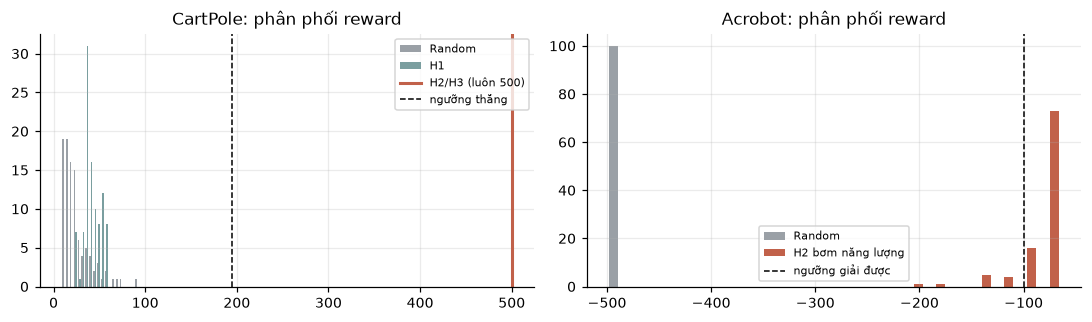

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist([cp_stats["Random"]["rewards"], cp_stats["H1: chỉ nhìn góc"]["rewards"]],
           bins=20, label=["Random", "H1"], color=["#9aa0a6", "#7a9e9f"])
ax[0].axvline(500, color="#c1614a", lw=2, label="H2/H3 (luôn 500)")
ax[0].axvline(195, color="k", ls="--", lw=1, label="ngưỡng thắng")
ax[0].set_title("CartPole: phân phối reward"); ax[0].legend(fontsize=7)

ax[1].hist([ac_stats["Random"]["rewards"], ac_stats["H2: bơm năng lượng"]["rewards"]],
           bins=20, label=["Random", "H2 bơm năng lượng"], color=["#9aa0a6", "#c1614a"])
ax[1].axvline(-100, color="k", ls="--", lw=1, label="ngưỡng giải được")
ax[1].set_title("Acrobot: phân phối reward"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

### Nhận xét
**CartPole.** Random đạt ~25 điểm — cột đổ sau chưa tới nửa giây mô phỏng. H1 (chỉ nhìn góc) tăng lên ~41,
tức **cải thiện 64% nhưng vẫn thất bại 100%**. Nguyên nhân: khi ta thấy góc dương và đẩy sang phải, cột đã
đang *xoay* theo chiều đó rồi — phản ứng luôn chậm một nhịp, biên độ dao động lớn dần tới khi vượt 12°.
Chỉ cần **thêm một số hạng vận tốc góc** (H2) là điểm nhảy từ 41 lên **500 tuyệt đối, 100% thắng**.
Bài học: thông tin đạo hàm quan trọng hơn việc tinh chỉnh hệ số.

**Acrobot.** Random đạt **đúng −500 ở cả 100 tập** — không một lần nào thắng. Mô-men cố định (H1) cũng vậy.
Heuristic bơm năng lượng đạt **−84.4, thắng 100%**, vượt xa ngưỡng "giải được" là −100. Một dòng lệnh
`return 2 if obs[5] > 0 else 0` đủ để giải quyết môi trường mà random không bao giờ chạm tới.

# B. Parameter Variation

Tham số vật lý nằm trên **`env.unwrapped`**, không phải trên đối tượng `env` do `gym.make()` trả về —
`gym.make` bọc môi trường trong các wrapper (`TimeLimit`, `OrderEnforcing`, `PassiveEnvChecker`).
Đặt `env.length = 2.0` sẽ tạo một thuộc tính vô nghĩa trên wrapper và **không báo lỗi**, khiến ta tưởng
đã đổi thành công. Đây là cái bẫy phổ biến nhất của phần này.

In [17]:
env = gym.make("CartPole-v1")
u = env.unwrapped
print("Tham số CartPole có thể chỉnh:")
for k in ["gravity", "masscart", "masspole", "length", "force_mag", "tau",
          "theta_threshold_radians", "x_threshold"]:
    print(f"  {k:26s} = {getattr(u, k)}")
env.close()

env = gym.make("Acrobot-v1"); u = env.unwrapped
print("\nTham số Acrobot có thể chỉnh:")
for k in ["LINK_LENGTH_1", "LINK_LENGTH_2", "LINK_MASS_1", "LINK_MASS_2",
          "LINK_COM_POS_1", "LINK_MOI", "MAX_VEL_1", "MAX_VEL_2",
          "AVAIL_TORQUE", "torque_noise_max"]:
    print(f"  {k:20s} = {getattr(u, k)}")
env.close()

Tham số CartPole có thể chỉnh:
  gravity                    = 9.8
  masscart                   = 1.0
  masspole                   = 0.1
  length                     = 0.5
  force_mag                  = 10.0
  tau                        = 0.02
  theta_threshold_radians    = 0.20943951023931953
  x_threshold                = 2.4

Tham số Acrobot có thể chỉnh:
  LINK_LENGTH_1        = 1.0
  LINK_LENGTH_2        = 1.0
  LINK_MASS_1          = 1.0
  LINK_MASS_2          = 1.0
  LINK_COM_POS_1       = 0.5
  LINK_MOI             = 1.0
  MAX_VEL_1            = 12.566370614359172
  MAX_VEL_2            = 28.274333882308138
  AVAIL_TORQUE         = [-1.0, 0.0, 1]
  torque_noise_max     = 0.0


## B1 CartPole - Quét từng tham số

In [18]:
def sweep(env_id, attr, values, policies, xlabel):
    recs = []
    for v in values:
        for pname, pol in policies:
            s = evaluate(env_id, pol, param_setter=setter(**{attr: v}))
            recs.append({xlabel: v, "agent": pname,
                         "Reward TB": round(s["mean_reward"], 2),
                         "Tỉ lệ thắng (%)": round(s["success_rate"], 1)})
    return pd.DataFrame(recs)

cp_pols = [("Random", random_agent), ("Heuristic H3", cartpole_pd_full)]

df_len = sweep("CartPole-v1", "length", [0.1, 0.25, 0.5, 1.0, 2.0], cp_pols, "length")
display(df_len.pivot(index="length", columns="agent", values="Reward TB"))

agent,Heuristic H3,Random
length,,
0.10,470.78,8.73
0.25,500.00,15.85
0.50,500.00,24.96
1.00,500.00,34.93
2.00,500.00,47.45


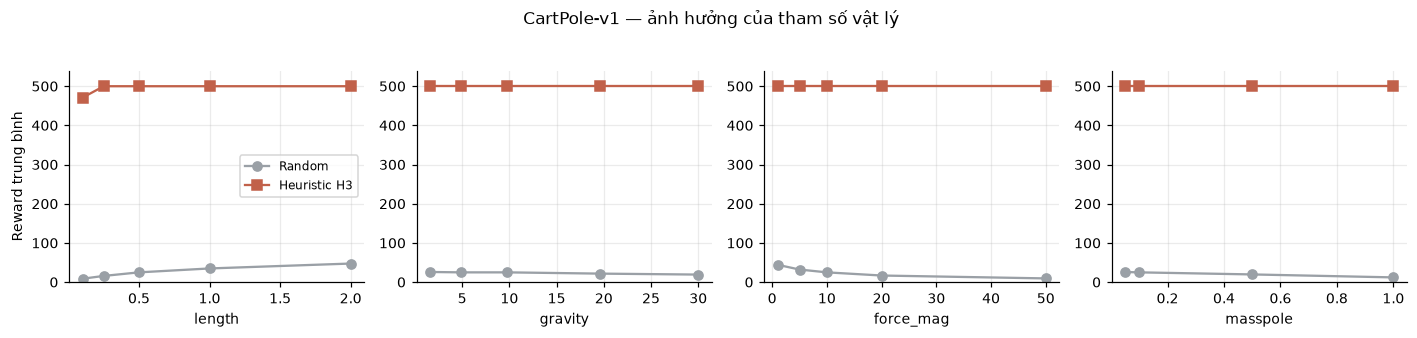

In [19]:
sweeps = {}
for attr, vals, lab in [("length",    [0.1, 0.25, 0.5, 1.0, 2.0],   "length"),
                        ("gravity",   [1.6, 4.9, 9.8, 19.6, 30.0],  "gravity"),
                        ("force_mag", [1.0, 5.0, 10.0, 20.0, 50.0], "force_mag"),
                        ("masspole",  [0.05, 0.1, 0.5, 1.0],        "masspole")]:
    sweeps[lab] = sweep("CartPole-v1", attr, vals, cp_pols, lab)

fig, axes = plt.subplots(1, 4, figsize=(13, 2.9))
for ax_, (lab, d) in zip(axes, sweeps.items()):
    for name, c, m in [("Random", "#9aa0a6", "o"), ("Heuristic H3", "#c1614a", "s")]:
        sub = d[d.agent == name]
        ax_.plot(sub[lab], sub["Reward TB"], m + "-", color=c, label=name)
    ax_.set_xlabel(lab); ax_.set_ylim(0, 540)
axes[0].set_ylabel("Reward trung bình"); axes[0].legend(fontsize=8)
plt.suptitle("CartPole-v1 — ảnh hưởng của tham số vật lý", y=1.04)
plt.tight_layout(); plt.show()

1. Cột dài hơn -> dễ hơn

2. Lực mạnh hơn -> khó hơn

## B2 CartPole - kết hợp tham số

In [26]:
hard_configs = [
    ("Mặc định",                      {}),
    ("Cột siêu ngắn (length=0.05)",   {"length": 0.05}),
    ("Cột ngắn + nặng",               {"length": 0.1, "masspole": 1.0}),
    ("Lực yếu (force=1)",             {"force_mag": 1.0}),
    ("Lực yếu + trọng lực mạnh",      {"force_mag": 2.0, "gravity": 30.0}),
    ("dt lớn (tau=0.05)",             {"tau": 0.05}),
    ("Tất cả khắc nghiệt",            {"length": 0.1, "masspole": 0.8, "gravity": 25.0,
                                       "force_mag": 3.0, "tau": 0.04}),
]
recs = []
for lab, kw in hard_configs:
    r_ = evaluate("CartPole-v1", random_agent,     param_setter=setter(**kw))
    h_ = evaluate("CartPole-v1", cartpole_pd_full, param_setter=setter(**kw))
    recs.append({"Cấu hình": lab,
                 "Random reward": round(r_["mean_reward"], 1),
                 "H3 reward": round(h_["mean_reward"], 1),
                 "H3 thắng (%)": round(h_["success_rate"], 1)})
display(pd.DataFrame(recs))

,Cấu hình,Random reward,H3 reward,H3 thắng (%)
0,Mặc định,25.0,500.0,100.0
1,Cột siêu ngắn (length=0.05),6.1,54.8,0.0
2,Cột ngắn + nặng,5.0,23.7,0.0
3,Lực yếu (force=1),44.3,500.0,100.0
4,Lực yếu + trọng lực mạnh,25.8,500.0,100.0
5,dt lớn (tau=0.05),7.7,500.0,100.0
6,Tất cả khắc nghiệt,4.4,8.7,0.0


3. Để có khả năng win -> cột rất ngắn (vì trong `u = θ + 0.5·θ̇` thì 0.5 đã được cố định)

## B3 Acrobot - quét tham số

In [21]:
ac_pols = [("Random", random_agent), ("Heuristic H2", acrobot_pump)]

df_l1 = sweep("Acrobot-v1", "LINK_LENGTH_1", [0.5, 0.75, 1.0, 1.5], ac_pols, "LINK_LENGTH_1")
df_m2 = sweep("Acrobot-v1", "LINK_MASS_2",   [0.5, 1.0, 2.0, 4.0],  ac_pols, "LINK_MASS_2")
display(df_m2.pivot(index="LINK_MASS_2", columns="agent", values="Tỉ lệ thắng (%)"))

agent,Heuristic H2,Random
LINK_MASS_2,,
0.5,99.0,15.0
1.0,100.0,0.0
2.0,100.0,0.0
4.0,0.0,0.0


In [22]:
# Quét biên độ mô-men: AVAIL_TORQUE là một danh sách nên cần setter riêng
def torque_setter(t):
    def f(u): u.AVAIL_TORQUE = [-t, 0.0, +t]
    return f

recs = []
for t in [0.25, 0.5, 1.0, 2.0, 4.0]:
    for name, pol in ac_pols:
        s = evaluate("Acrobot-v1", pol, param_setter=torque_setter(t))
        recs.append({"torque": t, "agent": name,
                     "Reward TB": round(s["mean_reward"], 2),
                     "Tỉ lệ thắng (%)": round(s["success_rate"], 1)})
df_tq = pd.DataFrame(recs)
display(df_tq.pivot(index="torque", columns="agent", values="Tỉ lệ thắng (%)"))

agent,Heuristic H2,Random
torque,,
0.25,100.0,0.0
0.50,97.0,0.0
1.00,100.0,0.0
2.00,100.0,59.0
4.00,100.0,99.0


In [23]:
# Đổi trọng lực Acrobot bằng cách kế thừa lớp (g bị hard-code trong _dsdt)
from numpy import cos, sin, pi
from gymnasium.envs.classic_control.acrobot import AcrobotEnv

class AcrobotGravity(AcrobotEnv):
    gravity = 9.8
    def _dsdt(self, s_augmented):
        m1, m2 = self.LINK_MASS_1, self.LINK_MASS_2
        l1 = self.LINK_LENGTH_1
        lc1, lc2 = self.LINK_COM_POS_1, self.LINK_COM_POS_2
        I1 = I2 = self.LINK_MOI
        g = self.gravity                              # <-- thay đổi duy nhất
        a, s = s_augmented[-1], s_augmented[:-1]
        theta1, theta2, dtheta1, dtheta2 = s
        d1 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*cos(theta2)) + I1 + I2
        d2 = m2*(lc2**2 + l1*lc2*cos(theta2)) + I2
        phi2 = m2*lc2*g*cos(theta1 + theta2 - pi/2.)
        phi1 = (-m2*l1*lc2*dtheta2**2*sin(theta2)
                - 2*m2*l1*lc2*dtheta2*dtheta1*sin(theta2)
                + (m1*lc1 + m2*l1)*g*cos(theta1 - pi/2) + phi2)
        ddtheta2 = ((a + d2/d1*phi1 - m2*l1*lc2*dtheta1**2*sin(theta2) - phi2)
                    / (m2*lc2**2 + I2 - d2**2/d1))
        ddtheta1 = -(d2*ddtheta2 + phi1)/d1
        return dtheta1, dtheta2, ddtheta1, ddtheta2, 0.

gym.register("AcrobotGravity-v0", entry_point=AcrobotGravity,
             max_episode_steps=500, reward_threshold=-100.0)

recs = []
for g_ in [1.6, 4.9, 9.8, 19.6, 30.0]:
    for name, pol in ac_pols:
        s = evaluate("AcrobotGravity-v0", pol, param_setter=setter(gravity=g_))
        recs.append({"gravity": g_, "agent": name,
                     "Reward TB": round(s["mean_reward"], 2),
                     "Tỉ lệ thắng (%)": round(s["success_rate"], 1)})
df_g = pd.DataFrame(recs)
display(df_g.pivot(index="gravity", columns="agent", values="Tỉ lệ thắng (%)"))

agent,Heuristic H2,Random
gravity,,
1.6,70.0,73.0
4.9,100.0,22.0
9.8,100.0,0.0
19.6,100.0,0.0
30.0,97.0,0.0


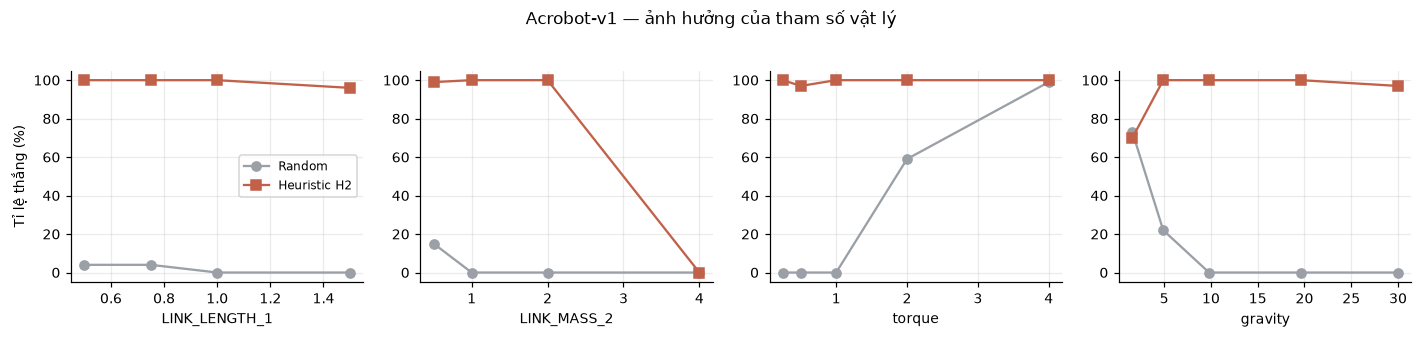

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(13, 2.9))
for ax_, (d, lab) in zip(axes, [(df_l1, "LINK_LENGTH_1"), (df_m2, "LINK_MASS_2"),
                                (df_tq, "torque"), (df_g, "gravity")]):
    for name, c, m in [("Random", "#9aa0a6", "o"), ("Heuristic H2", "#c1614a", "s")]:
        sub = d[d.agent == name]
        ax_.plot(sub[lab], sub["Tỉ lệ thắng (%)"], m + "-", color=c, label=name)
    ax_.set_xlabel(lab); ax_.set_ylim(-5, 105)
axes[0].set_ylabel("Tỉ lệ thắng (%)"); axes[0].legend(fontsize=8)
plt.suptitle("Acrobot-v1 — ảnh hưởng của tham số vật lý", y=1.04)
plt.tight_layout(); plt.show()

4. Biên độ của mo-men là vấn đề khó nhất của Acrobot

5. Trọng lực thấp làm khó Heuristic nhưng dễ cho random

6. Heuristic bền với nhiễu

In [25]:
recs = []
for nz in [0.0, 0.1, 0.3, 0.5, 1.0]:
    s = evaluate("Acrobot-v1", acrobot_pump, param_setter=setter(torque_noise_max=nz))
    recs.append({"torque_noise_max": nz, "Reward TB": round(s["mean_reward"], 1),
                 "Tỉ lệ thắng (%)": round(s["success_rate"], 1)})
display(pd.DataFrame(recs))

,torque_noise_max,Reward TB,Tỉ lệ thắng (%)
0,0.0,-84.4,100.0
1,0.1,-97.8,99.0
2,0.3,-95.1,99.0
3,0.5,-97.1,99.0
4,1.0,-95.0,100.0


Thêm nhiễu ngẫu nhiên vào mô-men với biên độ **bằng cả mô-men điều khiển** (`noise = 1.0`) chỉ làm
reward giảm từ −84 xuống −95, tỉ lệ thắng vẫn **100%**. Heuristic bơm năng lượng **bền vững** vì nó
dựa trên dấu của vận tốc góc — một đại lượng thay đổi chậm, nhiễu trung bình hoá gần như triệt tiêu.

# PHẦN D — Tổng hợp kết quả & phân tích

## D.1 Bảng kết quả chính (100 tập / cấu hình)

### CartPole-v1

| Agent | Reward TB | Độ lệch chuẩn | Số bước TB | Tỉ lệ thắng |
|---|---|---|---|---|
| Random | 24.96 | 15.38 | 25.0 | 0% |
| H1 — chỉ nhìn góc | 41.04 | 8.62 | 41.0 | 0% |
| H2 — PD (góc + vận tốc góc) | **500.00** | 0.00 | 500.0 | **100%** |
| H3 — PD + giữ xe ở tâm | **500.00** | 0.00 | 500.0 | **100%** |

### Acrobot-v1

| Agent | Reward TB | Độ lệch chuẩn | Số bước TB | Tỉ lệ thắng |
|---|---|---|---|---|
| Random | −500.00 | 0.00 | 500.0 | 0% |
| H1 — mô-men cố định | −500.00 | 0.00 | 500.0 | 0% |
| H2 — bơm năng lượng | **−84.35** | 24.27 | 85.4 | **100%** |

## D.2 Tham số nào ảnh hưởng mạnh nhất tới độ khó?

Xếp hạng theo mức chênh lệch tỉ lệ thắng / reward mà tham số tạo ra:

| Hạng | Môi trường | Tham số | Ảnh hưởng đo được |
|---|---|---|---|
| 1 | Acrobot | `AVAIL_TORQUE` | Random: **0% → 99%** thắng khi tăng 1.0 → 4.0 |
| 2 | Acrobot | `gravity` | Random: **0% → 73%** khi giảm 9.8 → 1.6 |
| 3 | Acrobot | `LINK_MASS_2` | Heuristic: **100% → 0%** khi tăng lên 4.0 |
| 4 | CartPole | `length` | Random: 8.7 → 47.5 điểm; bẻ gãy H3 ở 0.05 |
| 5 | CartPole | `force_mag` | Random: 44.3 → 9.5 điểm (mạnh hơn = khó hơn) |
| 6 | CartPole | `masspole` | Random: 25.8 → 12.1 điểm |
| 7 | CartPole | `gravity` | Random: 25.9 → 19.3 điểm (yếu nhất) |

**Kết luận chung:** tham số ảnh hưởng mạnh nhất là những tham số **thay đổi bản chất bài toán**, không
phải những tham số chỉ làm hệ "lắc mạnh hơn". Tăng mô-men Acrobot biến bài toán bơm năng lượng thành bài
toán nhấc thẳng — độ khó sụp đổ hoàn toàn. Còn đổi trọng lực CartPole chỉ làm mọi thứ nhanh/chậm hơn
đôi chút, cấu trúc bài toán không đổi.

## D.3 Chiến lược thắng — cái gì hiệu quả, cái gì không

**CartPole — điều đã hiệu quả**
- Thêm số hạng **vận tốc góc**: bước nhảy quyết định, 41 → 500 điểm. Nó biến bộ điều khiển từ *phản ứng*
  thành *dự đoán*.
- Thêm số hạng vị trí xe với hệ số **nhỏ** (0.02): không tăng điểm ở cấu hình mặc định (đã kịch trần 500)
  nhưng bảo hiểm cho các cấu hình xe trôi.

**CartPole — điều không hiệu quả**
- Chuỗi hành động cố định (một chiều, xen kẽ): không dùng phản hồi trạng thái nên chết dưới 50 bước.
- Luật chỉ dùng góc: cải thiện có nhưng không bao giờ đủ.
- Tinh chỉnh hệ số khi cấu trúc luật đã sai: vô ích. *Thêm biến quan trọng hơn chỉnh hệ số.*

**Acrobot — điều đã hiệu quả**
- **Bơm năng lượng theo dấu `θ̇2`**. Thay vì cố lái hệ tới tư thế đích (bất khả thi vì mô-men quá yếu),
  ta bỏ qua mục tiêu hoàn toàn và chỉ **bơm năng lượng liên tục**. Chiều cao tự đến như hệ quả.
- Heuristic này còn **bền với nhiễu** và hoạt động trên hầu hết các cấu hình tham số.

**Acrobot — điều không hiệu quả**
- Random và mô-men cố định: **0/100 tập thắng**, thất bại tuyệt đối.
- Thử lái trực tiếp theo góc (thay vì theo vận tốc): thất bại, vì hệ **thiếu truyền động**
  (underactuated) — không có chuỗi mô-men nào đưa thẳng tới đích nếu chưa đủ năng lượng.

## D.4 Bài học rút ra

1. **Reward thưa vs dày quyết định độ khó nhiều hơn vật lý.** CartPole cho tín hiệu hữu ích mỗi bước;
   Acrobot chỉ cho tín hiệu khi đã thắng. Random giải được một phần CartPole nhưng **không bao giờ**
   chạm tới Acrobot.
2. **Với hệ thiếu truyền động, đừng lái theo mục tiêu — hãy lái theo năng lượng.**
3. **"Độ khó" là thuộc tính của cặp (môi trường, agent).** Tăng `force_mag` làm random tệ đi 4.6 lần
   nhưng không ảnh hưởng gì tới heuristic.
4. **Heuristic viết tay chứa hằng số hiệu chỉnh ngầm.** H3 đạt 500/500 ở mặc định nhưng sụp còn 54.8
   khi cột ngắn đi 10 lần — không phải vì nguyên lý sai, mà vì hằng số 0.5 không còn đúng.
   Đây chính là khoảng trống mà RL lấp vào.
5. **Luôn dùng `env.unwrapped`.** Gán thuộc tính lên `env` không báo lỗi và âm thầm không có tác dụng.